## Резюме

Вот что мы рассмотрели в этой лекции.
- Сначала мы представили проблему классификации и кластеризации для векторных данных и важность выбора правильной меры для вычисления (нес)сходств между образцами.
- Затем мы представили три подхода к вычислению (нес)сходств в многомерных временных рядах.

1. DTW, метрика на основе выравнивания.

2. TCK, ядерное сходство.

3. Встраивание RC, подход к встраиванию временных рядов в векторные данные.
- Эти меры (нес)сходства являются краеугольным камнем в классификации и кластеризации временных рядов.
- После вычисления мы увидели, как их можно легко подключить к тому же методу классификации и кластеризации, который мы видели для векторных данных.

В заключение мы выделим основные плюсы и минусы трех подходов к вычислению (не)сходства MTS.

**DTW**

- ✅ В большинстве случаев хорошо работает с гиперпараметрами по умолчанию.
- ✅ Инвариантен к перемещениям во времени.
- ❌ Медленно.
- ❌ Не учитывает сложные динамические особенности.

**TCK**

- ✅ Гиперпараметры легко настраиваются.
- ✅ Обрабатывает отсутствующие данные.
- ❌ Очень медленно.

**RC-embedding**

- ✅ Быстро.
- ✅ Захватывает сложные динамические особенности.
- ❌ Множество гиперпараметров для установки.

- Каждый подход может достигать лучшей или худшей производительности в зависимости от данных и решаемой проблемы.
- Выбор оптимальной меры (несходства), алгоритма классификации/кластеризации и гиперпараметров часто является сложной процедурой.
- Это требует опыта и должно выполняться с использованием систематических подходов, таких как перекрестная проверка.

---

## Упражнения

Мы рассмотрим набор данных [Libras](https://www.timeseriesclassification.com/description.php?Dataset=Libras). Набор данных содержит 15 классов по 24 экземпляра в каждом. Каждый класс ссылается на тип движения руки в LIBRAS (португальское название «LÍngua BRAsileira de Sinais», официальный бразильский язык сигналов).

### Упражнение 1

1. Вычислите матрицу расстояний DTW.
2. Получите из нее матрицу сходства.
3. Постройте две матрицы. Прокомментируйте структуру, которую вы видите (не забудьте отсортировать элементы по классам).
4. Выполните классификацию с помощью классификаторов SVC и $k$-NN и сообщите:
- время обучения и тестирования,
- точность и оценку F1 на тестовом наборе.
5. Выполните иерархическую кластеризацию с помощью алгоритма Linkage Ward.
6. Постройте дендрограмму и проверьте ее, чтобы выбрать оптимальный порог для генерации кластерного раздела. Сообщите NMI для найденного вами раздела.
7. Выполните снижение размерности с помощью KernelPCA. Постройте результаты на двумерном графике.

In [2]:
!pip install dtaidistance tck reservoir_computing tsa_course

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 32.5 MB/s eta 0:00:00


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time
from dtaidistance import dtw_ndim
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, v_measure_score, normalized_mutual_info_score
from sklearn.decomposition import KernelPCA, PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import scipy.spatial.distance as ssd
from tck.datasets import DataLoader
from tck.TCK import TCK
from scipy.spatial.distance import pdist, squareform


/usr/local/lib/python3.12/dist-packages/tck/TCK.py:3: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [7]:
Xtr, Ytr, Xte, Yte = DataLoader().get_data('Libras')
Ytr, Yte = Ytr.ravel(), Yte.ravel()

Loaded Libras dataset.
Number of classes: 15
Data shapes:
  Xtr: (180, 45, 2)
  Ytr: (180, 1)
  Xte: (180, 45, 2)
  Yte: (180, 1)


In [8]:
X_all = np.concatenate([Xtr, Xte], axis=0)
Y_all = np.concatenate([Ytr, Yte], axis=0)
n_tr = len(Xtr)

In [9]:
full_dist = dtw_ndim.distance_matrix(X_all)

In [10]:
gamma = 1.0 / (np.median(full_dist[full_dist > 0])**2)
full_sim = np.exp(-gamma * full_dist**2)

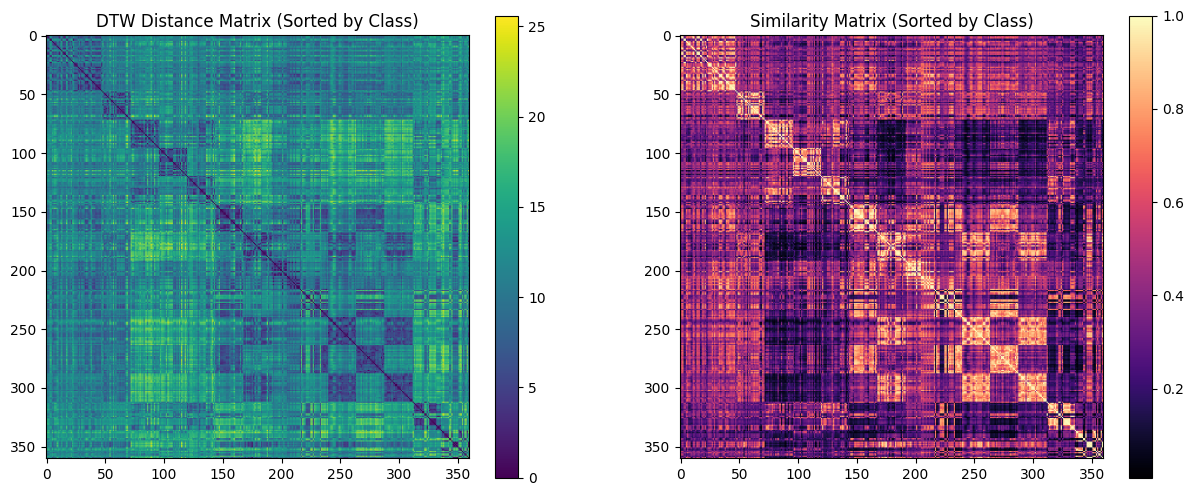

In [11]:
sort_idx = np.argsort(Y_all)
dist_sorted = full_dist[sort_idx][:, sort_idx]
sim_sorted = full_sim[sort_idx][:, sort_idx]

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
im1 = ax[0].imshow(dist_sorted, cmap='viridis')
ax[0].set_title("DTW Distance Matrix (Sorted by Class)")
plt.colorbar(im1, ax=ax[0])

im2 = ax[1].imshow(sim_sorted, cmap='magma')
ax[1].set_title("Similarity Matrix (Sorted by Class)")
plt.colorbar(im2, ax=ax[1])
plt.show()

In [12]:
dist_tr_tr = full_dist[:n_tr, :n_tr]
dist_te_tr = full_dist[n_tr:, :n_tr]

sim_tr_tr = full_sim[:n_tr, :n_tr]
sim_te_tr = full_sim[n_tr:, :n_tr]

svc = svm.SVC(kernel="precomputed")
start_train = time.time()
svc.fit(sim_tr_tr, Ytr)
t_train_svc = time.time() - start_train

start_test = time.time()
y_pred_svc = svc.predict(sim_te_tr)
t_test_svc = time.time() - start_test

knn = KNeighborsClassifier(n_neighbors=3, metric="precomputed")
start_train = time.time()
knn.fit(dist_tr_tr, Ytr)
t_train_knn = time.time() - start_train

start_test = time.time()
y_pred_knn = knn.predict(dist_te_tr)
t_test_knn = time.time() - start_test

print(f"SVC: Time Train/Test: {t_train_svc:.3f}/{t_test_svc:.3f}s | Acc: {accuracy_score(Yte, y_pred_svc):.3f} | F1: {f1_score(Yte, y_pred_svc, average='macro'):.3f}")
print(f"k-NN: Time Train/Test: {t_train_knn:.3f}/{t_test_knn:.3f}s | Acc: {accuracy_score(Yte, y_pred_knn):.3f} | F1: {f1_score(Yte, y_pred_knn, average='macro'):.3f}")

SVC: Time Train/Test: 0.011/0.002s | Acc: 0.778 | F1: 0.767
k-NN: Time Train/Test: 0.003/0.019s | Acc: 0.833 | F1: 0.828


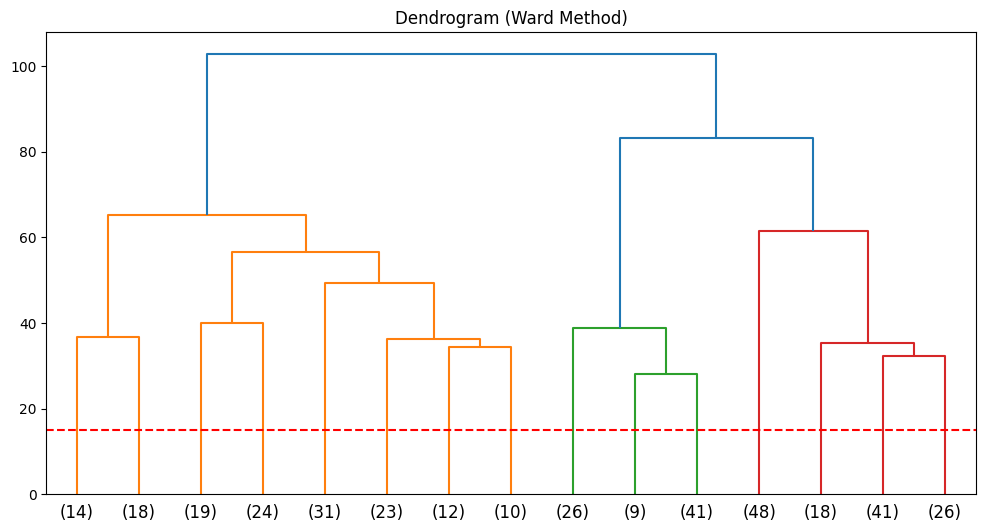

Количество найденных кластеров: 30
NMI Score: 0.7368


In [13]:
condensed_dist = ssd.squareform(full_dist)
Z = linkage(condensed_dist, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=15)
plt.title("Dendrogram (Ward Method)")
plt.axhline(y=15, color='r', linestyle='--')
plt.show()

optimal_threshold = 15
clusters = fcluster(Z, t=optimal_threshold, criterion='distance')

from sklearn.metrics import normalized_mutual_info_score
nmi = normalized_mutual_info_score(Y_all, clusters)
print(f"Количество найденных кластеров: {len(np.unique(clusters))}")
print(f"NMI Score: {nmi:.4f}")

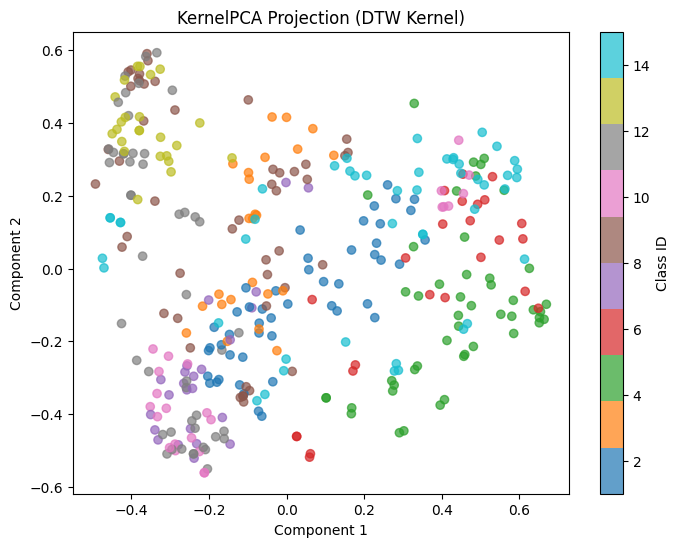

In [14]:
kpca = KernelPCA(n_components=2, kernel='precomputed')
X_embedded = kpca.fit_transform(full_sim)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=Y_all, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Class ID')
plt.title("KernelPCA Projection (DTW Kernel)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

### Упражнение 2

1. Добавьте 40% пропущенных значений к обучающим и тестовым данным.
2. Вычислите ядро ​​TCK.
3. Вычислите матрицу различий из ядра (попробуйте сделать дополнительное к тому, что вы сделали для получения сходства из DTW).

Повторите пункты 4–7 из предыдущего упражнения.

In [15]:
X_all = np.concatenate([Xtr, Xte], axis=0)
X_all_miss = X_all.copy()
X_all_miss[np.random.rand(*X_all_miss.shape) < 0.4] = np.nan

n_tr = len(Xtr)
n_te = len(Xte)

In [16]:
tck = TCK(G=10, C=20)
tck.fit(X_all_miss)

The dataset contains missing data

Training the TCK using the following parameters:
	C = 20, G = 10
	Number of MTS for each GMM: 288 - 360 (80 - 100 percent)
	Number of attributes sampled from [2, 2]
	Length of time segments sampled from [6, 25]




Fitting GMMs:   0%|          | 0/190 [00:00<?, ?it/s]

In [17]:
K_all = tck.predict(mode='tr-tr')

K_tr_tr = K_all[:n_tr, :n_tr]
K_te_tr = K_all[n_tr:, :n_tr]

dist_tr_tr = np.sqrt(np.abs(2 * (1 - K_tr_tr)))
dist_te_tr = np.sqrt(np.abs(2 * (1 - K_te_tr)))
dist_all = np.sqrt(np.abs(2 * (1 - K_all)))

Computing TCK (tr-tr):   0%|          | 0/190 [00:00<?, ?it/s]

In [18]:
svc = svm.SVC(kernel="precomputed")
svc.fit(K_tr_tr, Ytr.ravel())

SVC(kernel='precomputed')

In [19]:
y_pred_svc = svc.predict(K_te_tr)

In [20]:
knn = KNeighborsClassifier(n_neighbors=3, metric="precomputed")
knn.fit(dist_tr_tr, Ytr.ravel())

KNeighborsClassifier(metric='precomputed', n_neighbors=3)

In [21]:
y_pred_knn = knn.predict(dist_te_tr)

In [22]:
print(f"SVC Accuracy: {accuracy_score(Yte, y_pred_svc):.3f}")
print(f"k-NN Accuracy: {accuracy_score(Yte, y_pred_knn):.3f}")

SVC Accuracy: 0.783
k-NN Accuracy: 0.039


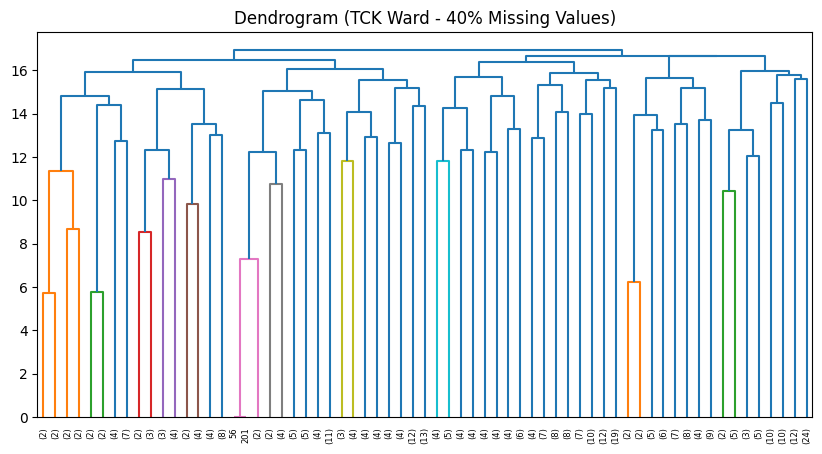

NMI Score: 0.4147


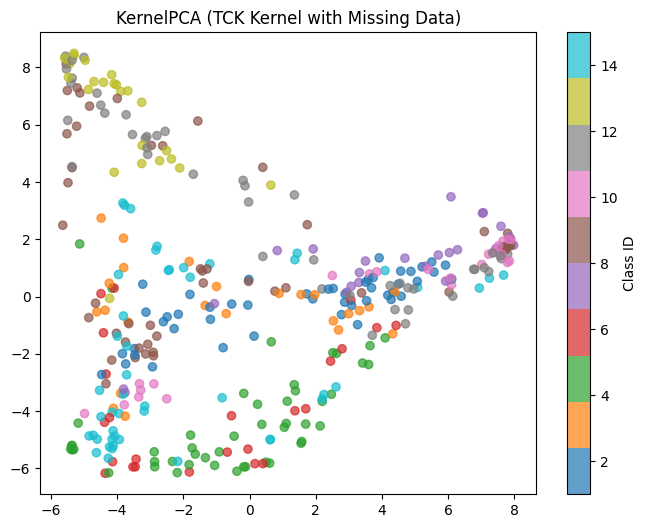

In [23]:
Z = linkage(ssd.squareform(dist_all, checks=False), method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Dendrogram (TCK Ward - 40% Missing Values)")
plt.show()

Y_all = np.concatenate([Ytr, Yte]).ravel()
clust_labels = fcluster(Z, t=Z[-1, 2]*0.5, criterion='distance')
print(f"NMI Score: {normalized_mutual_info_score(Y_all, clust_labels):.4f}")

kpca = KernelPCA(n_components=2, kernel='precomputed')
X_kpca = kpca.fit_transform(K_all)

plt.figure(figsize=(8, 6))
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=Y_all, cmap='tab10', alpha=0.7)
plt.title("KernelPCA (TCK Kernel with Missing Data)")
plt.colorbar(label='Class ID')
plt.show()

### Упражнение 3

1. Вычислите RC-вложения.
2. Получите матрицу сходства и различия из представлений MTS.

Повторите пункты 4–7 из предыдущих упражнений.

In [24]:
class SimpleRC:
    def __init__(self, n_internal_units=100, spectral_radius=0.9, input_scaling=0.1):
        self.n_internal_units = n_internal_units
        self.spectral_radius = spectral_radius
        self.input_scaling = input_scaling
        self.leaking_rate = 0.1

    def _init_weights(self, input_size):
        self.W_in = np.random.randn(self.n_internal_units, input_size) * self.input_scaling
        W = np.random.randn(self.n_internal_units, self.n_internal_units)
        eigenvalues = np.linalg.eigvals(W)
        spectral_radius_current = np.max(np.abs(eigenvalues))
        self.W = (W / spectral_radius_current) * self.spectral_radius

    def transform(self, X):
        if not hasattr(self, 'W_in'):
            self._init_weights(X[0].shape[1])

        embeddings = []
        for x in X:
            h = np.zeros(self.n_internal_units)
            for t in range(x.shape[0]):
                h = (1 - self.leaking_rate) * h + self.leaking_rate * np.tanh(
                    self.W_in @ x[t] + self.W @ h
                )
            embeddings.append(h)

        return np.array(embeddings)

In [25]:
X_all = np.concatenate([Xtr, Xte], axis=0)
Y_all = np.concatenate([Ytr, Yte], axis=0).ravel()
n_tr = len(Xtr)

In [26]:
rc = SimpleRC(n_internal_units=100, spectral_radius=0.9, input_scaling=0.1)
X_rc = rc.transform(X_all)

print(f"RC размер: {X_rc.shape}")

RC размер: (360, 100)


In [27]:
X_rc_tr = X_rc[:n_tr]
X_rc_te = X_rc[n_tr:]

In [28]:
print("Вычисление матриц сходства и различия...")
dist_rc = squareform(pdist(X_rc, metric='euclidean'))
dist_rc_tr_tr = dist_rc[:n_tr, :n_tr]
dist_rc_te_tr = dist_rc[n_tr:, :n_tr]

gamma = 1.0 / (np.median(dist_rc[dist_rc > 0])**2)
sim_rc = np.exp(-gamma * dist_rc**2)
sim_rc_tr_tr = sim_rc[:n_tr, :n_tr]
sim_rc_te_tr = sim_rc[n_tr:, :n_tr]

Вычисление матриц сходства и различия...


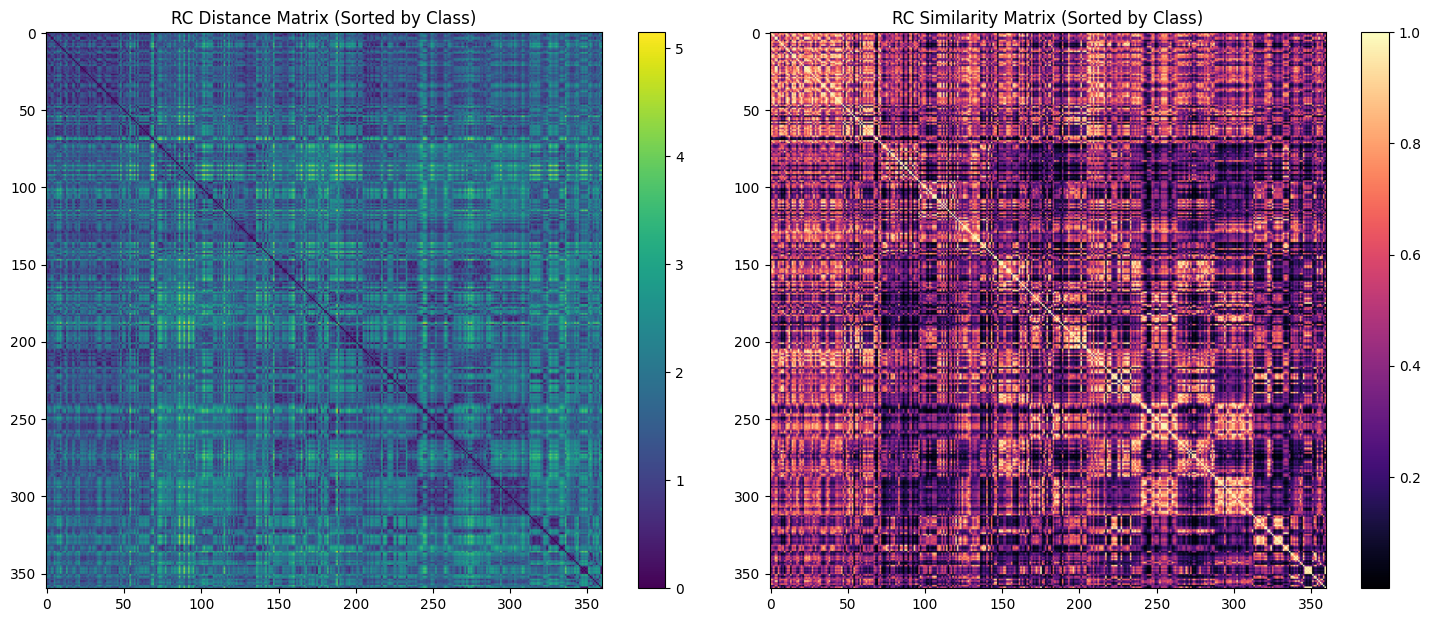

In [29]:
dist_sorted = dist_rc[sort_idx][:, sort_idx]
sim_sorted = sim_rc[sort_idx][:, sort_idx]

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
im1 = ax[0].imshow(dist_sorted, cmap='viridis')
ax[0].set_title("RC Distance Matrix (Sorted by Class)")
plt.colorbar(im1, ax=ax[0])

im2 = ax[1].imshow(sim_sorted, cmap='magma')
ax[1].set_title("RC Similarity Matrix (Sorted by Class)")
plt.colorbar(im2, ax=ax[1])
plt.tight_layout()
plt.show()

In [30]:
svc_rc = svm.SVC(kernel="precomputed", max_iter=2000)
start_train = time.time()
svc_rc.fit(sim_rc_tr_tr, Ytr.ravel())
t_train_svc_rc = time.time() - start_train

start_test = time.time()
y_pred_svc_rc = svc_rc.predict(sim_rc_te_tr)
t_test_svc_rc = time.time() - start_test

knn_rc = KNeighborsClassifier(n_neighbors=3, metric="precomputed")
start_train = time.time()
knn_rc.fit(dist_rc_tr_tr, Ytr.ravel())
t_train_knn_rc = time.time() - start_train

start_test = time.time()
y_pred_knn_rc = knn_rc.predict(dist_rc_te_tr)
t_test_knn_rc = time.time() - start_test

print(f"SVC: Time Train/Test: {t_train_svc_rc:.3f}/{t_test_svc_rc:.3f}s | Acc: {accuracy_score(Yte.ravel(), y_pred_svc_rc):.3f} | F1: {f1_score(Yte.ravel(), y_pred_svc_rc, average='macro'):.3f}")
print(f"k-NN: Time Train/Test: {t_train_knn_rc:.3f}/{t_test_knn_rc:.3f}s | Acc: {accuracy_score(Yte.ravel(), y_pred_knn_rc):.3f} | F1: {f1_score(Yte.ravel(), y_pred_knn_rc, average='macro'):.3f}")

SVC: Time Train/Test: 0.005/0.002s | Acc: 0.389 | F1: 0.373
k-NN: Time Train/Test: 0.002/0.005s | Acc: 0.422 | F1: 0.426


In [31]:
condensed_dist_rc = ssd.squareform(dist_rc)
Z_rc = linkage(condensed_dist_rc, method='ward')

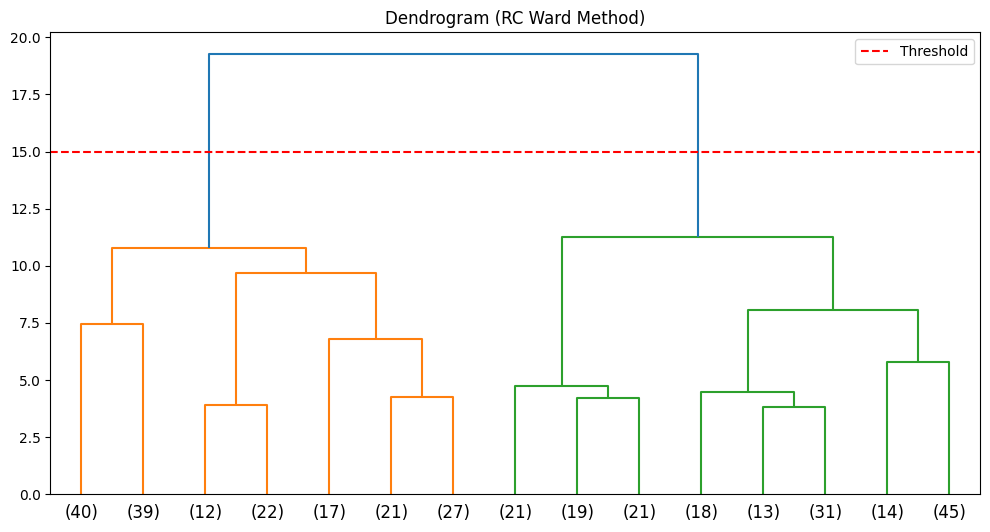

Количество найденных кластеров: 2
NMI Score: 0.0719


In [32]:
plt.figure(figsize=(12, 6))
dendrogram(Z_rc, truncate_mode='lastp', p=15)
plt.title("Dendrogram (RC Ward Method)")
plt.axhline(y=15, color='r', linestyle='--', label='Threshold')
plt.legend()
plt.show()

optimal_threshold_rc = 15
clusters_rc = fcluster(Z_rc, t=optimal_threshold_rc, criterion='distance')
nmi_rc = normalized_mutual_info_score(Y_all, clusters_rc)
print(f"Количество найденных кластеров: {len(np.unique(clusters_rc))}")
print(f"NMI Score: {nmi_rc:.4f}")

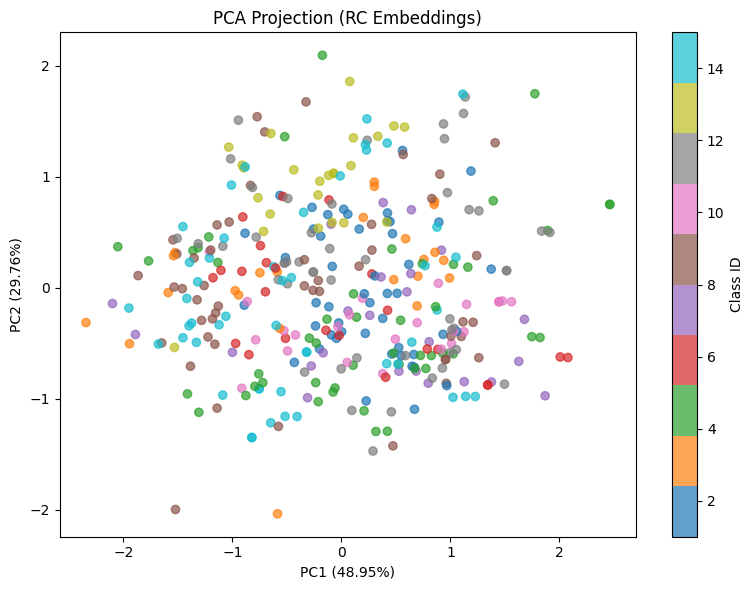

In [34]:
pca_rc = PCA(n_components=2)
X_pca_rc = pca_rc.fit_transform(X_rc)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_rc[:, 0], X_pca_rc[:, 1], c=Y_all, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Class ID')
plt.title("PCA Projection (RC Embeddings)")
plt.xlabel(f"PC1 ({pca_rc.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca_rc.explained_variance_ratio_[1]:.2%})")
plt.tight_layout()
plt.show()